# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 1d lattice.

<hr>

## Preliminaries

In [16]:
from essentials import *
dprs.__version__

'2026.4.16'

In [17]:
viz = Viz(dpi=125)

<hr>

## Parameters

Initial experiments, with "incorrect" bedload model (no collective, two-nbr effect):

In [18]:
# expts_tuple = (
#     dict(p_1=0.001, p_2=0.999,  p_3=0, scale=1.3),
#     dict(p_1=0.2682, p_2=0.9,     p_3=0, scale=1.03),
#     dict(p_1=0.45155, p_2=0.8,     p_3=0, scale=0.955),
#     dict(p_1=0.5855, p_2=0.7,     p_3=0, scale=0.935),
#     dict(p_1=0.64475, p_2=0.64475, p_3=0, scale=0.94),
#     dict(p_1=0.68705, p_2=0.6,     p_3=0, scale=0.935),
#     dict(p_1=0.76714, p_2=0.5,     p_3=0, scale=0.95),
#     dict(p_1=0.83180, p_2=0.4,     p_3=0, scale=0.975),
#     dict(p_1=0.88505, p_2=0.3,     p_3=0, scale=1.01),
#     dict(p_1=0.92961, p_2=0.2,     p_3=0, scale=1.072),
#     dict(p_1=0.96748, p_2=0.1,     p_3=0, scale=1.2),
#     dict(p_1=0.999, p_2=0.001,     p_3=0, scale=1.3),
# )
# expts = {i: expt for i, expt in enumerate(expts_tuple)}
# expt = expts[11]
# expt

"Correct" bedload model:

In [19]:
# growth_model = GrowthModel.BedloadA
# expts_tuple = (
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.5098, p_2=0.999,   p_3=0, scale=2.52),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.5304, p_2=0.99,    p_3=0, scale=1.75),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.55095, p_2=0.97,    p_3=0, scale=1.47),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.5641, p_2=0.95,    p_3=0, scale=1.33),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.58694, p_2=0.9,     p_3=0, scale=1.185),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.6159, p_2=0.8,     p_3=0, scale=1.05),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.63579, p_2=0.7,     p_3=0, scale=0.965),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.64475, p_2=0.64475, p_3=0, scale=0.94),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.65113, p_2=0.6,     p_3=0, scale=0.91),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.6635, p_2=0.5,     p_3=0, scale=0.87),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.6737, p_2=0.4,     p_3=0, scale=0.83),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.6837, p_2=0.3,     p_3=0, scale=0.825),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.6916, p_2=0.2,     p_3=0, scale=0.79),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.6986, p_2=0.1,     p_3=0, scale=0.77),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.7048, p_2=0.01,    p_3=0, scale=0.75),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.70538, p_2=0.001,   p_3=0, scale=0.75),
#     dict(n_x=1_000_000, n_iterations=3000, p_1=0.70542, p_2=0.000,   p_3=0, scale=0.75),
# )

growth_model = GrowthModel.BedloadB
expts_tuple = (
    dict(n_x=100_000, n_iterations=2000, p_1=0.2465, p_2=0.9, p_3=0, bias=1, scale=1.71),
    dict(n_x=200_000, n_iterations=10000, p_1=0.2471, p_2=0.9, p_3=0, bias=1, scale=1.75),
    dict(n_x=50_000,  n_iterations=10000, p_1=0.5924, p_2=0.5, p_3=0, bias=1, scale=0.98),
    dict(n_x=200_000, n_iterations=10000, p_1=0.5927, p_2=0.5, p_3=0, bias=1, scale=0.98),
    dict(n_x=1_000_000, n_iterations=3000, p_1=0.5927, p_2=0.5, p_3=0, bias=1, scale=0.98),
)

expts = {i: expt for i, expt in enumerate(expts_tuple)}
expt = expts[4]
expt

{'n_x': 1000000,
 'n_iterations': 3000,
 'p_1': 0.5927,
 'p_2': 0.5,
 'p_3': 0,
 'bias': 1,
 'scale': 0.98}

In [20]:
class Parameters:
    growth_model = growth_model
    dim = Dimension.D1
    n_x: int = expt["n_x"]
    n_y: int = 1
    n_z: int = 1
    p_1: float = expt["p_1"]
    p_2: float = expt["p_2"]
    p_3: float = expt["p_3"]
    bias: float = expt["bias"] if growth_model==GrowthModel.BedloadB else 0
    n_iterations: int = expt["n_iterations"]
    sample_period: int = 1
    initial_condition = InitialCondition.Randomized
    p_initial: float = 0.99
    random_seed: int = 1
    topology_x = Topology.Periodic
    topology_y = Topology.Unspecified
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()
parameters.bias

1

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [21]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [22]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [23]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 3001



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

In [24]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(1000000, 3001)

<hr>

## Visualization

### Phase diagram

In [25]:
if growth_model== GrowthModel.BedloadA:
    name: str = make_name(parameters, "phase_diagram",)
    title: str = "1d-DP bedload model"
    viz.phase_diagram(name, title, expts, i_equal=7,)
    plt.show()

### Evolution

In [26]:
viz_lattice_history = partial(
    viz.lattice_history,
    lattices=lattices, 
    p=parameters, 
    x=min(parameters.n_x, 1000),
    t=min(n_lattices, 1001),
    fig_size=(6, 4,),
)

lattice_history_p0p592700_s1_nx1000000


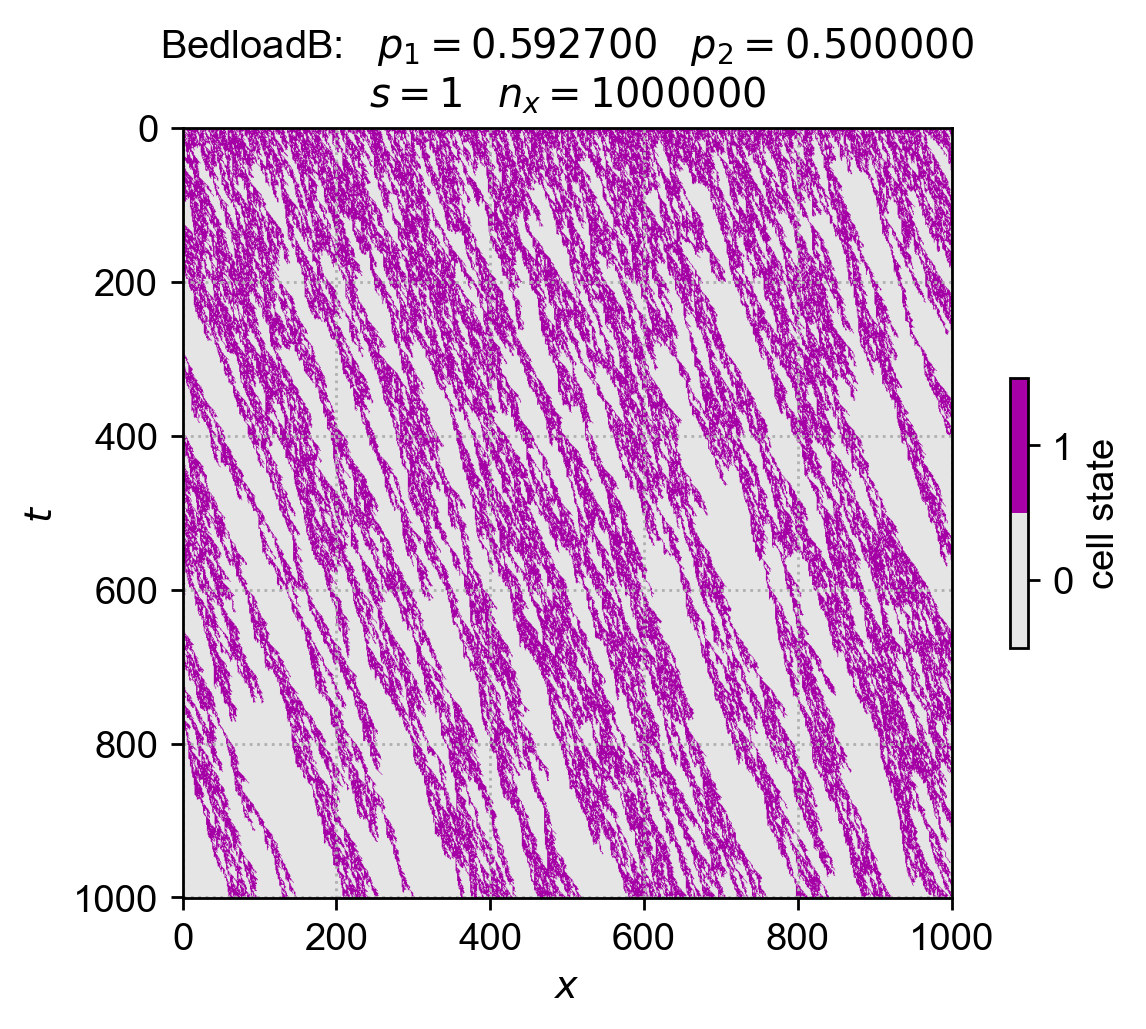

In [27]:
i_slice: int
if n_lattices>0:
    i_slice = 0
    name = make_name(parameters, "lattice_history",)
    print(name)
    viz_lattice_history(
        name=name, title=make_title(parameters), 
    )
    plt.show()

### Mean order parameter $t$-decay

ρmean_p0p592700_s1_nx1000000


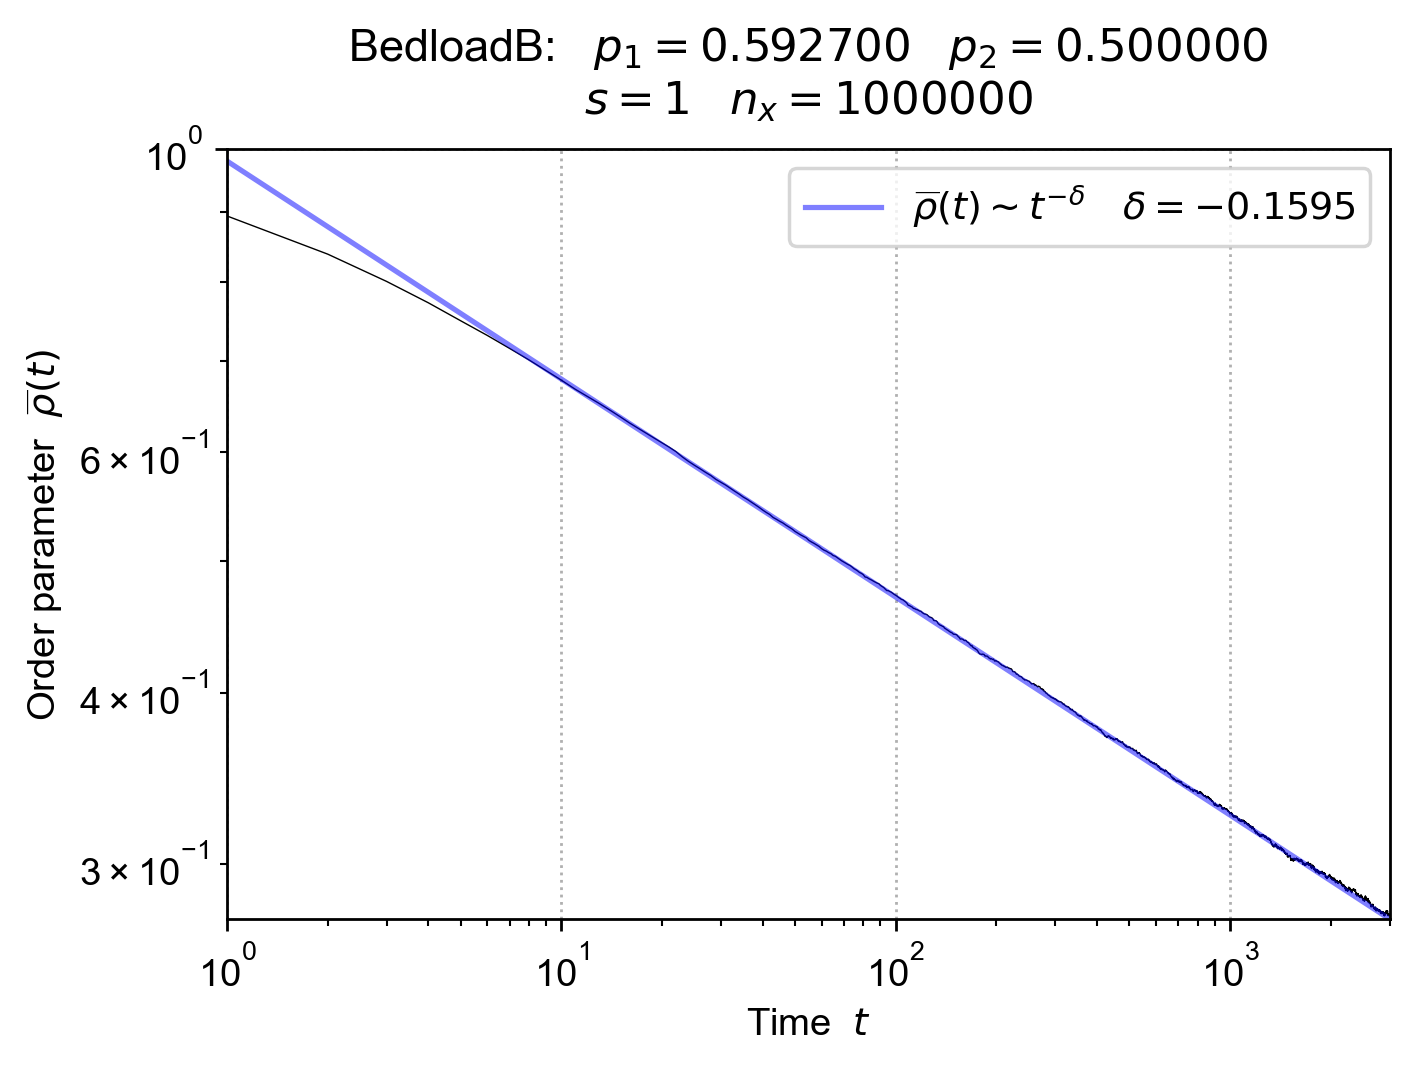

In [28]:
δ = 0.1594646
scale = expt["scale"]
        
name = make_name(parameters, "ρmean", None, )
print(name)
viz.lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=0,
    do_ref_curve=True,
)
plt.ylim(None, 1)
plt.show()

In [40]:
i_offset: int = parameters.n_iterations//50
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(rf"Estimated t-decay exponent:  δ = {np.round(exponent,3):0.3f}")

t range: 60.0-3000.0
Estimated t-decay exponent:  δ = -0.159


<hr>

## Export

In [30]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "bedload1d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/bedload1d'